# Multi-Dimensional Return Forecasting & Portfolio Management
### 6-Stock Indian Equity Universe: RELIANCE, HDFCBANK, INFY, M&M, BHARTIARTL, HUL

**Assignment 2 — Data Science & AI**

> **Ticker substitution note:** TAMO (Tata Motors) has been replaced with **M&M (Mahindra & Mahindra)** per instructions. M&M plays the role of the high-beta/cyclical name in this universe (auto sector), same role TAMO would have played — the cross-symbol robustness checks later in this notebook specifically guard against over-tuning to it.

---
## Pipeline Overview

```
1. Setup & Config                     7. Feature Selection (MI + RFE + Lasso)
2. Data Acquisition (5 sources)       8. Interaction Features + Rolling Standardization
3. Panel Construction & Target Def.   9. Chronological / Walk-Forward Split
4. Feature Engineering (30+ feats)   10. Nested Walk-Forward CV + Model Training
5. Leakage Audit                     11. Evaluation & Cross-Symbol Robustness
6. Missing Data & Winsorization      12. Portfolio Construction & Performance
```


## Step 1: Setup & Installs

In [1]:
# Run once. Restart runtime after if prompted.
!pip install -q yfinance feature_engine optuna lightgbm xgboost transformers torch feedparser vaderSentiment pandas_datareader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 3.2 MB/s eta 0:00:00


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, re, json

import yfinance as yf

import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor
from sklearn.metrics import (r2_score, mean_absolute_error, accuracy_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit
from feature_engine.outliers import Winsorizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded')


Libraries loaded


In [3]:
# ============================================================
# CONFIG — universe, dates, tickers
# ============================================================
# TAMO -> M&M substitution per instructions
TICKERS = {
    'RELIANCE':   'RELIANCE.NS',
    'HDFCBANK':   'HDFCBANK.NS',
    'INFY':       'INFY.NS',
    'M&M':        'M&M.NS',
    'BHARTIARTL': 'BHARTIARTL.NS',
    'HUL':        'HINDUNILVR.NS',
}

# Benchmark: NIFTY 50, not a single-sector index. Rationale: the 6-stock
# universe spans Energy/Conglomerate, Banking, IT, Auto, Telecom, and FMCG —
# there is no single sector index that is a fair "home sector" for all six,
# so we residualize every stock's return against the broad market (NIFTY 50)
# instead of a sector index. This keeps the "outperform sector" framing from
# the reference (ITC) pipeline while making it valid across a mixed universe.
BENCHMARK_TICKER = '^NSEI'

START_DATE       = '2020-01-01'
END_DATE         = '2025-12-31'
FORWARD_TEST_START = '2025-10-01'   # holdout: Oct-Dec 2025, per assignment
FORWARD_TEST_END   = '2025-12-31'

print(f'Universe: {list(TICKERS.keys())}')
print(f'Benchmark: {BENCHMARK_TICKER}')
print(f'Data window: {START_DATE} -> {END_DATE}')
print(f'Forward test (held out): {FORWARD_TEST_START} -> {FORWARD_TEST_END}')


Universe: ['RELIANCE', 'HDFCBANK', 'INFY', 'M&M', 'BHARTIARTL', 'HUL']
Benchmark: ^NSEI
Data window: 2020-01-01 -> 2025-12-31
Forward test (held out): 2025-10-01 -> 2025-12-31


## Step 2: Data Acquisition

Five sources, each with its own frequency and its own alignment rule (this mirrors the reference ITC pipeline's alignment table, generalized to 6 tickers):

| Source | Fields | Frequency | Alignment rule |
|---|---|---|---|
| Yahoo Finance | OHLCV per stock + `^NSEI` benchmark | Daily | native |
| Yahoo Finance | USD/INR, India VIX, Brent crude, US 10Y yield | Daily | forward-filled on holiday gaps |
| **FRED (`INDIRLTLT01STM`)** | **India 10-Year Government Bond Yield** | Monthly | forward-filled to daily, `merge_asof` for the monthly print itself |
| RBI (hardcoded policy timeline) | Repo rate | Step function (event-dated) | `merge_asof(direction='backward')` |
| MoSPI (hardcoded, sourced Aug 2026) | CPI YoY inflation | Monthly | mapped by year-month |
| Yahoo Finance `.quarterly_financials` / `.quarterly_balance_sheet` | Revenue, Net Income, EPS, ROE, D/E, P/E | Quarterly | `merge_asof(direction='backward')` on a date **shifted +45 days past quarter-end** — see Step 2d |
| Google News RSS (date-bounded, monthly) + FinBERT | Daily sentiment polarity per stock | Daily (still sparse pre-2023) | shifted +1 day lag, gaps filled with 0 (neutral) |

**Why not scrape MoneyControl directly (as the assignment suggests)?** MoneyControl's fundamentals pages are JS-rendered and change markup often, making a scraper break silently — a serious risk for a pipeline meant to run unattended. `yfinance`'s `quarterly_financials`/`quarterly_balance_sheet` cover the same fields (Revenue, Net Income, Equity, Debt, shares outstanding → EPS/ROE/D/E/P-E) from a single already-used, stable API. This substitution is explicitly allowed by the assignment ("feel free to use other data and data sources").

**India 10Y G-Sec yield:** the assignment specifically asks for this, so it's now fetched directly rather than only proxied. FRED (via `pandas_datareader`, free, no API key) carries it as OECD series `INDIRLTLT01STM` — "Long-Term Government Bond Yields: 10-Year: India". It's **monthly**, forward-filled to daily like the CPI series (same honest limitation as the reference pipeline's own macro fields — a monthly print can't be made daily without either forward-filling or fabricating interpolation, and forward-filling is the standard, leakage-safe convention). If FRED is unreachable, the fetch falls back to `NaN` (later dropped/handled like any other macro gap) rather than silently substituting something else — check the printed warning if this happens. The repo rate / VIX / crude / US-10Y basket from before is kept as *additional* features, not a replacement.


In [4]:
# ============================================================
# 2a. OHLCV — stocks + benchmark
# ============================================================
def fetch_ohlcv(ticker, start=START_DATE, end=END_DATE):
    '''Daily adjusted OHLCV from Yahoo Finance.'''
    try:
        df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.rename(columns=str.lower)[['open', 'high', 'low', 'close', 'volume']]
        df.index.name = 'date'
        df = df.reset_index()
        return df
    except Exception as e:
        print(f'  [WARN] OHLCV fetch failed for {ticker}: {e}')
        return pd.DataFrame(columns=['date', 'open', 'high', 'low', 'close', 'volume'])

print('Fetching OHLCV for all 6 stocks + benchmark ...')
raw_ohlcv = {}
for name, tkr in TICKERS.items():
    print(f'  {name} ({tkr}) ...')
    raw_ohlcv[name] = fetch_ohlcv(tkr)
    time.sleep(0.5)  # be polite to the endpoint

benchmark_df = fetch_ohlcv(BENCHMARK_TICKER)
benchmark_df = benchmark_df.rename(columns={'close': 'close_bench'})[['date', 'close_bench']]

for name, df in raw_ohlcv.items():
    print(f'  {name}: {df.shape[0]} rows' + (f'  ({df["date"].min().date()} -> {df["date"].max().date()})' if len(df) else '  [EMPTY]'))


Fetching OHLCV for all 6 stocks + benchmark ...
  RELIANCE (RELIANCE.NS) ...
  HDFCBANK (HDFCBANK.NS) ...
  INFY (INFY.NS) ...
  M&M (M&M.NS) ...
  BHARTIARTL (BHARTIARTL.NS) ...
  HUL (HINDUNILVR.NS) ...
  RELIANCE: 1486 rows  (2020-01-01 -> 2025-12-30)
  HDFCBANK: 1486 rows  (2020-01-01 -> 2025-12-30)
  INFY: 1486 rows  (2020-01-01 -> 2025-12-30)
  M&M: 1486 rows  (2020-01-01 -> 2025-12-30)
  BHARTIARTL: 1486 rows  (2020-01-01 -> 2025-12-30)
  HUL: 1486 rows  (2020-01-01 -> 2025-12-30)


In [5]:
# ============================================================
# 2b. MACRO — USD/INR, India VIX, Brent crude, US 10Y yield (Yahoo Finance)
#     + India 10Y G-Sec yield (FRED, monthly, ffilled to daily)
# ============================================================
from pandas_datareader import data as pdr

MACRO_TICKERS = {
    'usdinr':     'USDINR=X',
    'india_vix':  '^INDIAVIX',
    'brent_crude':'BZ=F',
    'us_10y':     '^TNX',
}

INDIA_10Y_FRED_CODE = 'INDIRLTLT01STM'  # OECD/FRED: India 10Y Govt Bond Yield, monthly

def fetch_macro():
    frames = []
    for name, tkr in MACRO_TICKERS.items():
        try:
            d = yf.download(tkr, start=START_DATE, end=END_DATE, progress=False)
            if isinstance(d.columns, pd.MultiIndex):
                d.columns = d.columns.get_level_values(0)
            s = d['Close'].rename(name)
            frames.append(s)
        except Exception as e:
            print(f'  [WARN] macro fetch failed for {name} ({tkr}): {e}')
    macro = pd.concat(frames, axis=1).reset_index().rename(columns={'Date': 'date'})

    # --- India 10Y G-Sec yield, the assignment's explicitly-named macro field ---
    try:
        g = pdr.DataReader(INDIA_10Y_FRED_CODE, 'fred', START_DATE, END_DATE)
        g = g.rename(columns={INDIA_10Y_FRED_CODE: 'india_10y_yield'}).reset_index().rename(columns={'DATE': 'date'})
        macro = macro.merge(g, on='date', how='outer').sort_values('date')
    except Exception as e:
        print(f'  [WARN] FRED fetch failed for India 10Y yield ({INDIA_10Y_FRED_CODE}): {e}')
        print('  Proceeding without india_10y_yield -- repo_rate/india_vix/us_10y basket still covers macro rate risk.')
        macro['india_10y_yield'] = np.nan

    macro = macro.sort_values('date').ffill()  # forward-fill holiday gaps AND the monthly FRED print
    return macro

print('Fetching macro indicators ...')
macro_df = fetch_macro()
print(f'Macro shape: {macro_df.shape}')
macro_df.tail()


Fetching macro indicators ...
Macro shape: (1583, 6)


,date,usdinr,india_vix,brent_crude,us_10y,india_10y_yield
1578,2025-12-23,89.603897,9.38,62.380001,4.169,6.6325
1579,2025-12-24,89.507896,9.19,62.240002,4.136,6.6325
1580,2025-12-26,90.105904,9.15,60.639999,4.136,6.6325
1581,2025-12-29,89.829300,9.72,61.939999,4.116,6.6325
1582,2025-12-30,89.900002,9.68,61.919998,4.130,6.6325


In [6]:
# ============================================================
# 2c. RBI POLICY REPO RATE — hand-verified step timeline (event-dated)
#     Source: RBI MPC announcements, cross-checked Aug 2026.
#     merge_asof(direction='backward') below simulates "the rate in effect
#     on trading day T", i.e. no look-ahead.
# ============================================================
REPO_RATE_EVENTS = pd.DataFrame({
    'date': pd.to_datetime([
        '2020-01-01', '2020-03-27', '2020-05-22',
        '2022-05-04', '2022-06-08', '2022-08-05', '2022-09-30', '2022-12-07',
        '2023-02-08',
        '2025-02-07', '2025-04-09', '2025-06-06', '2025-12-05',
    ]),
    'repo_rate': [
        5.15, 4.40, 4.00,
        4.40, 4.90, 5.40, 5.90, 6.25,
        6.50,
        6.25, 6.00, 5.50, 5.25,
    ]
}).sort_values('date')

# ============================================================
# 2c-ii. CPI (YoY) — monthly, from MoSPI press releases (anchor points,
#        linearly interpolated between releases; approximate by construction,
#        same practical compromise the reference ITC pipeline made).
# ============================================================
CPI_ANCHORS = {
    '2020-01': 7.59, '2020-06': 6.09, '2020-12': 4.59,
    '2021-06': 6.26, '2021-12': 5.59,
    '2022-06': 7.01, '2022-12': 5.72,
    '2023-06': 4.81, '2023-12': 5.69,
    '2024-06': 5.08, '2024-07': 3.54, '2024-08': 3.65, '2024-11': 5.48, '2024-12': 5.22,
    '2025-01': 4.31, '2025-05': 2.82, '2025-08': 2.07, '2025-12': 2.86,
}
_cpi_series = pd.Series(CPI_ANCHORS)
_cpi_series.index = pd.to_datetime(_cpi_series.index)
_cpi_full_idx = pd.date_range(_cpi_series.index.min(), '2025-12-31', freq='MS')
CPI_MONTHLY = _cpi_series.reindex(_cpi_full_idx).interpolate().rename('cpi_inflation')
CPI_MONTHLY.index.name = 'date'
print('CPI monthly series built:', CPI_MONTHLY.shape[0], 'months')


CPI monthly series built: 72 months


In [7]:
# ============================================================
# 2d. FUNDAMENTALS — quarterly, via yfinance financial statements
#     (substituted for MoneyControl scraping — see rationale above)
# ============================================================
# REPORTING LAG: `quarterly_financials`/`quarterly_balance_sheet` are
# indexed by QUARTER-END date (e.g. 2024-03-31), not the date the company
# actually announced results. A company's Q4 numbers are not public
# knowledge on Mar 31 -- SEBI's LODR regulations require listed companies
# to disclose quarterly results within 45 days of quarter-end (60 days
# for the Q4/annual result). Using the raw quarter-end date as the
# `merge_asof(direction='backward')` key would let the model see Q4
# fundamentals starting Apr 1, ~6-8 weeks before they actually existed --
# textbook look-ahead bias. We shift the effective "available as of" date
# forward by a conservative reporting lag before it's ever joined to price
# data, so `build_panel`'s merge_asof only ever sees a quarter's numbers
# after they would have realistically been public.
REPORTING_LAG_DAYS = 45   # SEBI LODR Reg. 33: max 45 days post quarter-end (60 for Q4/annual)

def fetch_fundamentals(ticker):
    '''Pulls quarterly Revenue, Net Income, Equity, Debt, EPS, shares
    outstanding and derives Revenue_Growth, Profit_Growth, ROE, D/E, EPS.
    P/E is computed later once we have daily close price. Returns 'date'
    already shifted forward by REPORTING_LAG_DAYS -- i.e. 'date' means
    "earliest day this quarter's numbers could be used", not quarter-end.'''
    try:
        t = yf.Ticker(ticker)
        fin = t.quarterly_financials.T          # Revenue, Net Income
        bal = t.quarterly_balance_sheet.T        # Total Debt, Total Equity
        fin.index = pd.to_datetime(fin.index)
        bal.index = pd.to_datetime(bal.index)

        out = pd.DataFrame(index=fin.index)
        out['Revenue']    = fin.get('Total Revenue', fin.get('Operating Revenue'))
        out['Net_Income'] = fin.get('Net Income')
        out = out.join(bal, how='left')
        out['Total_Equity'] = bal.get('Stockholders Equity', bal.get('Common Stock Equity'))
        out['Total_Debt']   = bal.get('Total Debt', bal.get('Long Term Debt'))
        out['Shares_Out']   = t.get_shares_full(start=START_DATE, end=END_DATE)\
                                 .resample('Q').last() if hasattr(t, 'get_shares_full') else np.nan

        out = out.sort_index()
        out['Revenue_Growth'] = out['Revenue'].pct_change(4) * 100   # YoY, 4 quarters
        out['Profit_Growth']  = out['Net_Income'].pct_change(4) * 100
        out['Profit_Margin']  = out['Net_Income'] / out['Revenue'] * 100
        out['ROE'] = out['Net_Income'] / out['Total_Equity'] * 100
        out['Debt_Equity'] = out['Total_Debt'] / out['Total_Equity']
        out['EPS'] = out['Net_Income'] / out['Shares_Out'] if 'Shares_Out' in out else np.nan

        out = out.reset_index().rename(columns={'index': 'quarter_end'})
        out['date'] = out['quarter_end'] + pd.Timedelta(days=REPORTING_LAG_DAYS)  # <-- the actual fix
        return out[['date', 'quarter_end', 'Revenue', 'Net_Income', 'Revenue_Growth', 'Profit_Growth',
                     'Profit_Margin', 'ROE', 'Debt_Equity', 'EPS']]
    except Exception as e:
        print(f'  [WARN] fundamentals fetch failed for {ticker}: {e}')
        return pd.DataFrame(columns=['date', 'quarter_end', 'Revenue', 'Net_Income', 'Revenue_Growth',
                                      'Profit_Growth', 'Profit_Margin', 'ROE', 'Debt_Equity', 'EPS'])

print('Fetching quarterly fundamentals ...')
fundamentals = {}
for name, tkr in TICKERS.items():
    print(f'  {name} ...')
    fundamentals[name] = fetch_fundamentals(tkr)
    time.sleep(0.5)


Fetching quarterly fundamentals ...
  RELIANCE ...
  HDFCBANK ...
  INFY ...
  M&M ...
  BHARTIARTL ...
  HUL ...


In [8]:
# ============================================================
# 2e. NEWS SENTIMENT — Google News RSS (free, no API key) + FinBERT
# ============================================================
import feedparser
from urllib.parse import quote

def fetch_headlines(company_name, start=None, end=None):
    '''Google News RSS search — free, no key. If start/end are given, uses
    Google's `after:`/`before:` search operators to bound the query to
    that window, which is what actually lets us reach back into 2020-2024
    (a single unqualified query only ever returns recent items — Google
    News RSS does not expose deep history any other way for a free,
    key-less query).'''
    q = f'{company_name} stock India'
    if start is not None and end is not None:
        q += f' after:{pd.Timestamp(start).date()} before:{pd.Timestamp(end).date()}'
    url = f'https://news.google.com/rss/search?q={quote(q)}&hl=en-IN&gl=IN&ceid=IN:IN'
    try:
        feed = feedparser.parse(url)
        rows = []
        for entry in feed.entries:
            pub = pd.to_datetime(entry.get('published', None), errors='coerce')
            rows.append({'date': pub, 'headline': entry.get('title', '')})
        # A query with zero matching articles is a completely normal, expected
        # outcome (most months for most tickers will have some), NOT an error
        # -- rows=[] here, and pd.DataFrame([]) has no columns at all, so
        # .dropna(subset=['date']) would raise a KeyError ("['date']") purely
        # because there's nothing to look up. Without this explicit check that
        # KeyError falls into the except block below and prints a false-alarm
        # "[WARN] ... failed" for what is actually just "no headlines this
        # month" -- across ~72 months x 6 tickers, a lot of months will
        # legitimately have zero hits, so this was firing constantly and
        # drowning out any warnings that reflect a real problem.
        if len(rows) == 0:
            return pd.DataFrame(columns=['date', 'headline'])
        return pd.DataFrame(rows).dropna(subset=['date'])
    except Exception as e:
        print(f'    [WARN] headline fetch failed for {company_name} [{start}:{end}]: {e}')
        return pd.DataFrame(columns=['date', 'headline'])

def fetch_headlines_historical(company_name, start=START_DATE, end=END_DATE, max_workers=8):
    '''Loops the date-bounded query month-by-month across the full window
    so historical coverage isn't just whatever a single "latest" query
    happens to surface. This is still bounded by what Google News RSS
    indexes at all for older stories (it is not a full archive), but it
    is materially broader than one unqualified query -- expect coverage
    to still be thinner for 2020-2022 than for 2024-2025, and treat that
    as a known, disclosed limitation rather than a bug.

    Runs the 72 monthly requests CONCURRENTLY (max_workers threads) rather
    than one-at-a-time with a fixed sleep between each -- these are I/O-
    bound HTTP requests, so threading gives a real speedup here (GIL isn't
    a bottleneck for waiting on network responses). Was previously ~72
    sequential requests x (network latency + 0.3s sleep) per ticker, which
    is most of why this cell took so long; concurrency caps load on the
    endpoint the same way the old sleep did, just via "at most N in
    flight" instead of "one at a time, paced by a timer".'''
    months = pd.date_range(start, end, freq='MS')

    def _fetch_month(m_start):
        m_end = (m_start + pd.offsets.MonthEnd(1))
        return fetch_headlines(company_name, start=m_start, end=m_end)

    all_heads = []
    covered_months = 0
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = [pool.submit(_fetch_month, m) for m in months]
        for fut in as_completed(futures):
            h = fut.result()
            if len(h):
                all_heads.append(h)
                covered_months += 1
    print(f'    ({covered_months}/{len(months)} months returned at least one headline)')
    if not all_heads:
        return pd.DataFrame(columns=['date', 'headline'])
    return pd.concat(all_heads, ignore_index=True).drop_duplicates(subset=['date', 'headline'])

# --- FinBERT sentiment scoring ---
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch

_FINBERT_NAME = 'ProsusAI/finbert'
_finbert_tok, _finbert_model = None, None

def _load_finbert():
    global _finbert_tok, _finbert_model
    if _finbert_model is None:
        # use_safetensors=True: without this, some repos (this one included)
        # cause the HF loader to pull down BOTH pytorch_model.bin AND
        # model.safetensors -- two formats of the identical ~438MB weights,
        # so ~880MB instead of ~440MB for no benefit, since only one is ever
        # actually used. Forcing safetensors-only halves that download.
        _finbert_tok = AutoTokenizer.from_pretrained(_FINBERT_NAME)
        _finbert_model = AutoModelForSequenceClassification.from_pretrained(_FINBERT_NAME, use_safetensors=True)
        _finbert_model.eval()
    return _finbert_tok, _finbert_model

def score_sentiment(headlines):
    '''Returns polarity in [-1, 1]: P(positive) - P(negative) from FinBERT.
    Labels for ProsusAI/finbert are [positive, negative, neutral].'''
    if len(headlines) == 0:
        return pd.Series(dtype=float)
    tok, model = _load_finbert()
    scores = []
    with torch.no_grad():
        for i in range(0, len(headlines), 32):
            batch = headlines[i:i+32]
            inputs = tok(batch, return_tensors='pt', padding=True, truncation=True, max_length=64)
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1).numpy()
            scores.extend(probs[:, 0] - probs[:, 1])  # P(pos) - P(neg)
    return pd.Series(scores)

def build_sentiment_series(company_name):
    '''End-to-end: headlines (month-by-month, 2020-2025) -> FinBERT
    polarity -> daily mean.
    IMPORTANT LEAKAGE GUARD: sentiment for day T must only use headlines
    published on or before day T, and is joined to the model on a +1 day
    lag (see build_panel below) — same discipline as the price/macro data.'''
    heads = fetch_headlines_historical(company_name)
    if len(heads) == 0:
        return pd.DataFrame(columns=['date', 'sentiment'])
    heads['sentiment'] = score_sentiment(heads['headline'].tolist())
    heads['date'] = heads['date'].dt.normalize()
    daily = heads.groupby('date')['sentiment'].mean().reset_index()
    return daily

print('Fetching + scoring news sentiment (month-by-month 2020-2025; downloads')
print('FinBERT ~440MB on first run; ~72 requests/ticker so this is the slowest cell) ...')
sentiment = {}
for name in TICKERS:
    print(f'  {name} ...')
    sentiment[name] = build_sentiment_series(name)
    print(f'    -> {len(sentiment[name])} days with coverage'
          + (f' ({sentiment[name]["date"].min().date()} -> {sentiment[name]["date"].max().date()})' if len(sentiment[name]) else ''))


Fetching + scoring news sentiment (month-by-month 2020-2025; downloads
FinBERT ~440MB on first run; ~72 requests/ticker so this is the slowest cell) ...
  RELIANCE ...
    (72/72 months returned at least one headline)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

    -> 1174 days with coverage (2020-01-02 -> 2025-12-30)
  HDFCBANK ...
    (72/72 months returned at least one headline)
    -> 1244 days with coverage (2020-01-02 -> 2025-12-28)
  INFY ...
    (63/72 months returned at least one headline)
    -> 282 days with coverage (2020-01-11 -> 2025-12-28)
  M&M ...
    (72/72 months returned at least one headline)
    -> 535 days with coverage (2020-01-01 -> 2025-12-31)
  BHARTIARTL ...
    (36/72 months returned at least one headline)
    -> 66 days with coverage (2020-04-04 -> 2025-12-30)
  HUL ...
    (72/72 months returned at least one headline)
    -> 691 days with coverage (2020-01-06 -> 2025-12-30)


**On sentiment coverage:** the month-by-month, date-bounded query above is a real improvement over a single "latest headlines" query, but it's still working against a structural limit: Google News RSS (like most free-tier news search) simply doesn't index every story from 2020-2022 the way it does recent ones, so **expect coverage to still be thinner for the earlier years than for 2024-2025** even after this change — that's a property of what's indexed, not something more looping fixes. The pipeline handles the gaps correctly rather than pretending they don't exist: missing sentiment-days are filled with **0 (neutral)**, not dropped or interpolated, so the model can still learn from the days sentiment *is* available without fabricating signal on days it isn't. If a paid news API (e.g. NewsAPI.org, or GDELT's proper date-ranged archive) is available, swap it into `fetch_headlines` — the FinBERT scoring and leakage-safe join below are source-agnostic.

## Step 3: Panel Construction & Target Definition

For each stock:
1. Join benchmark close price → compute stock return and benchmark return.
2. Join macro (ffill), repo rate (`merge_asof` backward), CPI (monthly map), fundamentals (`merge_asof` backward — simulates real-world reporting lag), sentiment (lag +1, fill 0).
3. Define the **target**: next-day return residualized against the market —

$$\text{target}_{t} = r^{stock}_{t+1} - r^{market}_{t+1}$$

Positive → the stock is expected to outperform the market next day.


In [9]:
def build_panel(name, tkr):
    df = raw_ohlcv[name].copy()
    if len(df) == 0:
        print(f'  [SKIP] {name}: no OHLCV data')
        return pd.DataFrame()

    df = df.merge(benchmark_df, on='date', how='left')
    df = df.sort_values('date').reset_index(drop=True)

    df['return_pct']        = df['close'].pct_change() * 100
    df['bench_return_pct']  = df['close_bench'].pct_change() * 100

    # Target: NEXT-day residualized return (shift -1 so target at row t
    # uses information only available strictly after close on day t)
    df['target_raw_return']    = df['return_pct'].shift(-1)
    df['target_residualized']  = df['target_raw_return'] - df['bench_return_pct'].shift(-1)

    # --- macro (ffill already applied at source) ---
    df = df.merge(macro_df, on='date', how='left').ffill()

    # --- repo rate: as-of backward join (no look-ahead) ---
    df = pd.merge_asof(df.sort_values('date'), REPO_RATE_EVENTS.sort_values('date'),
                        on='date', direction='backward')

    # --- CPI: map by year-month ---
    ym = df['date'].dt.to_period('M').dt.to_timestamp()
    df['cpi_inflation'] = ym.map(CPI_MONTHLY)

    # --- fundamentals: as-of backward join on the reporting-lag-shifted
    #     'date' (see Step 2d) -- this 'date' means "earliest day this
    #     quarter's numbers could actually be known", so backward-asof here
    #     genuinely has no look-ahead, unlike joining on raw quarter-end.
    FUND_COLS = ['Revenue','Net_Income','Revenue_Growth','Profit_Growth','Profit_Margin','ROE','Debt_Equity','EPS']
    fdf = fundamentals[name].dropna(subset=['date']).sort_values('date')[['date'] + FUND_COLS] if len(fundamentals[name]) else fundamentals[name]
    if len(fdf):
        df = pd.merge_asof(df.sort_values('date'), fdf, on='date', direction='backward')
        df['PE'] = df['close'] / df['EPS']
    else:
        for c in FUND_COLS:
            df[c] = np.nan
        df['PE'] = np.nan

    # --- sentiment: +1 day lag, fill neutral (0) on gaps ---
    sdf = sentiment[name].copy()
    if len(sdf):
        sdf['date'] = sdf['date'] + pd.Timedelta(days=1)   # yesterday's news -> today's feature
        df = df.merge(sdf, on='date', how='left')
    else:
        df['sentiment'] = np.nan
    df['sentiment'] = df['sentiment'].fillna(0.0)

    df['stock_id'] = name
    return df

print('Building per-stock panels ...')
panels = {}
for name, tkr in TICKERS.items():
    panels[name] = build_panel(name, tkr)
    print(f'  {name}: {panels[name].shape}')


Building per-stock panels ...
  RELIANCE: (1486, 29)
  HDFCBANK: (1486, 29)
  INFY: (1486, 29)
  M&M: (1486, 29)
  BHARTIARTL: (1486, 29)
  HUL: (1486, 29)


## Step 4: Feature Engineering — Technical Indicators

Same feature family as the reference pipeline (SMA/EMA, RSI, MACD, Bollinger Bands, buying/selling pressure, lagged returns/volume), applied per stock via `groupby` so no rolling window ever crosses from one ticker into another.


In [10]:
def add_technical_features(df):
    df = df.copy()
    eps = 1e-9

    df['buying_pressure']  = (df['close'] - df['low'])  / (df['high'] - df['low'] + eps)
    df['selling_pressure'] = (df['high'] - df['close']) / (df['high'] - df['low'] + eps)

    for w in [5, 10, 20, 50]:
        df[f'sma_{w}'] = df['close'].rolling(w).mean()
    for s in [12, 26]:
        df[f'ema_{s}'] = df['close'].ewm(span=s, adjust=False).mean()

    df['macd'] = df['ema_12'] - df['ema_26']
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['rsi_14'] = 100 - (100 / (1 + gain / loss))

    df['bb_mid'] = df['close'].rolling(20).mean()
    bb_std = df['close'].rolling(20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * bb_std
    df['bb_lower'] = df['bb_mid'] - 2 * bb_std
    df['bb_bandwidth'] = (df['bb_upper'] - df['bb_lower']) / df['bb_mid']
    df['bb_pct'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + eps)

    for lag in [1, 2, 3, 5]:
        df[f'return_lag{lag}'] = df['return_pct'].shift(lag)
        df[f'volume_lag{lag}'] = df['volume'].shift(lag)

    # volume z-score (30-day) — flags unusual activity, same spirit as ITC's 'high_volume'
    roll_mean = df['volume'].rolling(30).mean()
    roll_std  = df['volume'].rolling(30).std()
    df['volume_z'] = (df['volume'] - roll_mean) / roll_std.replace(0, np.nan)

    return df

for name in TICKERS:
    if len(panels[name]):
        panels[name] = add_technical_features(panels[name])

full_panel = pd.concat(panels.values(), ignore_index=True)
full_panel = full_panel.sort_values(['stock_id', 'date']).reset_index(drop=True)
print(f'Combined panel: {full_panel.shape[0]} rows x {full_panel.shape[1]} cols across {full_panel["stock_id"].nunique()} tickers')
full_panel.tail()


Combined panel: 8916 rows x 54 cols across 6 tickers


,date,open,high,low,close,volume,close_bench,return_pct,bench_return_pct,target_raw_return,target_residualized,usdinr,india_vix,brent_crude,us_10y,india_10y_yield,repo_rate,cpi_inflation,Revenue,Net_Income,Revenue_Growth,Profit_Growth,Profit_Margin,ROE,Debt_Equity,EPS,PE,sentiment,stock_id,buying_pressure,selling_pressure,sma_5,sma_10,sma_20,sma_50,ema_12,ema_26,macd,macd_signal,rsi_14,bb_mid,bb_upper,bb_lower,bb_bandwidth,bb_pct,return_lag1,volume_lag1,return_lag2,volume_lag2,return_lag3,volume_lag3,return_lag5,volume_lag5,volume_z
8911,2025-12-23,1573.624198,1573.624198,1560.883060,1563.471069,7506564,26177.150391,-0.298343,0.018149,-0.795818,-0.661920,89.603897,9.38,62.380001,4.169,6.6325,5.25,2.86,2.436320e+12,2.699400e+11,NaN,NaN,11.079825,NaN,NaN,NaN,NaN,0.000000,RELIANCE,0.203122,0.796878,1552.820386,1546.539441,1544.732794,1501.929700,1547.660562,1533.188092,14.472470,14.923351,65.440362,1544.732794,1572.438361,1517.027228,0.035871,0.838168,0.658111,10184852.0,1.340319,13937275.0,0.000000,6580829.0,-0.893196,11731856.0,-0.650028
8912,2025-12-24,1565.461954,1568.448147,1546.449881,1551.028687,8815745,26142.099609,-0.795818,-0.133898,0.064174,0.445929,89.507896,9.19,62.240002,4.136,6.6325,5.25,2.86,2.436320e+12,2.699400e+11,NaN,NaN,11.079825,NaN,NaN,NaN,NaN,0.504692,RELIANCE,0.208144,0.791856,1555.567676,1548.659631,1544.150488,1505.576836,1548.178735,1534.509618,13.669117,14.672504,60.035505,1544.150488,1570.735143,1517.565833,0.034433,0.629364,-0.298343,7506564.0,0.658111,10184852.0,1.340319,13937275.0,0.136160,7116649.0,-0.257672
8913,2025-12-26,1547.544758,1553.815812,1547.146696,1552.024048,2311495,26042.300781,0.064174,-0.381755,-0.872239,-0.487476,90.105904,9.15,60.639999,4.136,6.6325,5.25,2.86,2.436320e+12,2.699400e+11,NaN,NaN,11.079825,NaN,NaN,NaN,NaN,0.274794,RELIANCE,0.731334,0.268666,1558.514038,1550.073096,1543.941455,1509.225962,1548.770322,1535.806983,12.963339,14.330671,58.563527,1543.941455,1570.190658,1517.692252,0.034003,0.653959,-0.795818,8815745.0,-0.298343,7506564.0,0.658111,10184852.0,0.000000,6580829.0,-1.903640
8914,2025-12-29,1547.743942,1550.929166,1536.495899,1538.486694,5972105,25942.099609,-0.872239,-0.384763,-0.375259,-0.362731,89.829300,9.72,61.939999,4.116,6.6325,5.25,2.86,2.436320e+12,2.699400e+11,NaN,NaN,11.079825,NaN,NaN,NaN,NaN,-0.944206,RELIANCE,0.137931,0.862069,1554.632007,1548.988110,1542.851495,1512.636194,1547.188225,1536.005480,11.182745,13.701086,51.085133,1542.851495,1568.031696,1517.671295,0.032641,0.413329,0.064174,2311495.0,-0.795818,8815745.0,-0.298343,7506564.0,1.340319,13937275.0,-0.919791
8915,2025-12-30,1539.880194,1546.449794,1530.722584,1532.713379,8815884,25938.849609,-0.375259,-0.012528,-0.375259,-0.362731,89.900002,9.68,61.919998,4.130,6.6325,5.25,2.86,2.436320e+12,2.699400e+11,NaN,NaN,11.079825,NaN,NaN,NaN,NaN,-0.752612,RELIANCE,0.126583,0.873417,1547.544775,1547.355664,1541.542548,1515.453169,1544.961326,1535.761621,9.199705,12.800810,54.642876,1541.542548,1565.920742,1517.164353,0.031628,0.318913,-0.872239,5972105.0,0.064174,2311495.0,-0.795818,8815745.0,0.658111,10184852.0,-0.211660


## Step 5: Data-Leakage Audit

Same discipline as the reference pipeline, extended for the extra sources here:

| Excluded | Why |
|---|---|
| `close, high, low, open, close_bench` | non-stationary raw prices |
| `return_pct, bench_return_pct` | today's return — target predicts *tomorrow's* |
| `target_raw_return` | alternate target, not a feature |
| `date, stock_id` | identifiers, not model inputs (stock_id is one-hot encoded separately for the pooled model, see Step 9) |

Everything else — technical indicators (all computed via `.shift()`/`.rolling()` so they only see the past), macro, repo rate, CPI, fundamentals (backward as-of joined), sentiment (+1-day lagged) — is leakage-safe **by construction**, not by after-the-fact filtering.


In [11]:
META_COLS   = ['date', 'stock_id']
TARGET_COLS = ['target_residualized', 'target_raw_return']
LEAKY_COLS  = ['close', 'high', 'low', 'open', 'close_bench', 'return_pct', 'bench_return_pct']
EXCLUDE = META_COLS + TARGET_COLS + LEAKY_COLS

numeric_cols = full_panel.select_dtypes(include=[np.number]).columns.tolist()
candidate_features = [c for c in numeric_cols if c not in EXCLUDE]

FUNDAMENTAL_COLS = [c for c in ['Revenue','Net_Income','Revenue_Growth','Profit_Growth',
                                 'Profit_Margin','ROE','Debt_Equity','EPS','PE'] if c in candidate_features]

print(f'Numeric columns: {len(numeric_cols)}')
print(f'Excluded (meta+target+leaky): {len(EXCLUDE)}')
print(f'Fundamental (kept, not winsorized): {len(FUNDAMENTAL_COLS)}')
print(f'Feature candidates: {len(candidate_features)}')
print(candidate_features)


Numeric columns: 52
Excluded (meta+target+leaky): 11
Fundamental (kept, not winsorized): 9
Feature candidates: 43
['volume', 'usdinr', 'india_vix', 'brent_crude', 'us_10y', 'india_10y_yield', 'repo_rate', 'cpi_inflation', 'Revenue', 'Net_Income', 'Revenue_Growth', 'Profit_Growth', 'Profit_Margin', 'ROE', 'Debt_Equity', 'EPS', 'PE', 'sentiment', 'buying_pressure', 'selling_pressure', 'sma_5', 'sma_10', 'sma_20', 'sma_50', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'rsi_14', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_bandwidth', 'bb_pct', 'return_lag1', 'volume_lag1', 'return_lag2', 'volume_lag2', 'return_lag3', 'volume_lag3', 'return_lag5', 'volume_lag5', 'volume_z']


## Step 6: Missing Data Handling & Winsorization

- Drop columns >15% missing (per-stock, computed on the pooled panel — a column missing for one ticker only is still likely usable, so we check globally first and inspect per-ticker before dropping anything borderline).
- Drop rows lost to technical-indicator warm-up (first ~50 rows per ticker) and the final row per ticker (target needs `t+1`, so the last row has no target).
- Winsorize continuous features at 1st/99th percentile **within each stock's own history** (not pooled) — a "normal" volume for RELIANCE is a very different number from HUL, so pooling before winsorizing would clip perfectly ordinary observations for the larger-cap names.


In [12]:
# Ratio features (PE = close/EPS, Debt_Equity, ROE) can produce +/-inf
# rather than NaN when their denominator is ~0 for a given quarter (a
# breakeven EPS, or near-zero equity for a distressed quarter) -- both are
# realistic with live fundamentals data, not edge cases to dismiss. inf
# silently passes every dropna() call below (dropna only catches NaN), and
# then breaks mutual_info_regression / sklearn estimators outright ("Input
# contains infinity"), further downstream in Step 7 -- so it has to be
# neutralized here, at the source, not patched where it happens to surface.
inf_counts = np.isinf(full_panel[candidate_features]).sum()
inf_cols = inf_counts[inf_counts > 0]
if len(inf_cols):
    print(f'Replacing +/-inf with NaN in: {dict(inf_cols)}')
full_panel[candidate_features] = full_panel[candidate_features].replace([np.inf, -np.inf], np.nan)

nan_pct = full_panel[candidate_features + TARGET_COLS].isnull().mean() * 100
cols_to_drop = nan_pct[nan_pct > 15].index.tolist()
if cols_to_drop:
    print(f'Dropping columns with >15% NaN (pooled): {cols_to_drop}')
    candidate_features = [c for c in candidate_features if c not in cols_to_drop]

rows_before = len(full_panel)
df_clean = full_panel.dropna(subset=['target_residualized']).copy()
df_clean = df_clean.dropna(subset=candidate_features)
print(f'Dropped {rows_before - len(df_clean)} rows (warm-up / no-target / inf-ratio). Remaining: {len(df_clean)}')

# Winsorize per-stock. Skip columns feature_engine's Winsorizer would
# consider "degenerate" for a given stock's history.
#
# IMPORTANT: the right test for this is NOT `nunique()` -- a column can
# have plenty of unique values and still trip the Winsorizer's internal
# check, which is based on median absolute deviation (MAD):
#   scale = (col - col.median()).abs().median() / 0.67449
# `sentiment` is a good example: it's neutral-filled with 0 on every day
# with no news (see Step 3), so more than half its values can be exactly
# 0 even while the sparse real FinBERT scores give it dozens of distinct
# values. Its median is then 0 and its MAD is 0 -> the Winsorizer raises
# regardless of capping_method, because MAD=0 makes any capping ill-
# defined, not because 'quantiles' specifically needs more spread.
# We replicate that exact test here instead of approximating it.
def _has_positive_mad(s):
    med = s.median()
    mad = (s - med).abs().median()
    return mad > 0

wins_candidates = [c for c in candidate_features if c not in FUNDAMENTAL_COLS]
wins_parts = []
for sid, g in df_clean.groupby('stock_id'):
    g = g.copy()
    usable = [c for c in wins_candidates if _has_positive_mad(g[c])]
    skipped = set(wins_candidates) - set(usable)
    if skipped:
        print(f'  [{sid}] skipping winsorization for zero-MAD columns: {sorted(skipped)}')
    if usable:
        winsorizer = Winsorizer(capping_method='quantiles', tail='both', fold=0.01, variables=usable)
        g = winsorizer.fit_transform(g)
    wins_parts.append(g)
df_wins = pd.concat(wins_parts).sort_values(['stock_id', 'date']).reset_index(drop=True)
print(f'Winsorized (per-stock, variation-permitting) {len(wins_candidates)} candidate features.')


Dropping columns with >15% NaN (pooled): ['Revenue', 'Net_Income', 'Revenue_Growth', 'Profit_Growth', 'Profit_Margin', 'ROE', 'Debt_Equity', 'EPS', 'PE']
Dropped 294 rows (warm-up / no-target / inf-ratio). Remaining: 8622
  [BHARTIARTL] skipping winsorization for zero-MAD columns: ['sentiment']
  [HUL] skipping winsorization for zero-MAD columns: ['sentiment']
  [INFY] skipping winsorization for zero-MAD columns: ['sentiment']
  [M&M] skipping winsorization for zero-MAD columns: ['sentiment']
Winsorized (per-stock, variation-permitting) 34 candidate features.


## Step 7: Feature Selection — Domain-Grouped Mutual Information + RFE (Lasso)

Two complementary passes, as required by the assignment ("Implement feature selection (e.g., RFE) and regularization"):

1. **Domain-grouped Mutual Information** (from the reference pipeline) — within families of near-duplicate features (e.g. `sma_5`/`sma_10`/`sma_20`/`sma_50`), keep only the single best one. This directly fights multicollinearity between engineered indicators.
2. **Recursive Feature Elimination with L1 (Lasso) regularization** on the MI-selected survivors — this is the assignment's explicit overfitting safeguard, and it's applied *after* MI pruning so it's not wasted eliminating features that are obviously redundant.

**No-look-ahead in feature selection itself:** both passes are decisions about *which features to use at all* — not per-row transforms — so they must never be informed by data from the forward-test window, or the choice of features would itself be tuned on the test period. We carve the forward-test rows out **before** computing any MI score or fitting RFE, using only the strictly-pre-`FORWARD_TEST_START` pool for both. The resulting feature list is then applied uniformly to build the full modeling table (Step 8-9) — applying a *fixed, already-chosen* transform to test rows is fine and necessary (the model needs those columns to predict on); what's not fine, and what this fixes, is letting test-period target values influence *which* columns get chosen in the first place.


In [13]:
# Carve out the forward-test window BEFORE any feature-selection decision.
# This is the fix: previously MI/RFE were fit on the full `df_wins` (which
# includes Oct-Dec 2025), so the forward-test period's own target values
# could influence which features were selected -- a form of look-ahead
# bias baked into the experimental design, not the row-level data.
fs_pool = df_wins[df_wins['date'] < FORWARD_TEST_START].copy()
print(f'Feature-selection pool (strictly pre-forward-test): {len(fs_pool)} rows, '
      f'up to {fs_pool["date"].max().date()} (forward test starts {FORWARD_TEST_START})')

y_all = fs_pool['target_residualized']
X_all = fs_pool[candidate_features].copy()

# Defensive second guard: even after the inf->NaN pass in Step 6, a
# multiplicative combination downstream (or a fresh inf from a column
# that was on the winsorization skip-list, e.g. `sentiment`) could
# reintroduce +/-inf. mutual_info_regression has no tolerance for it,
# so clip rather than trust the data is already clean.
X_all = X_all.replace([np.inf, -np.inf], np.nan)

mi_scores = mutual_info_regression(X_all.fillna(0), y_all, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

DOMAIN_GROUPS = {
    'SMA':          [c for c in X_all.columns if c.startswith('sma_')],
    'EMA/MACD':     [c for c in X_all.columns if c.startswith('ema_') or c.startswith('macd')],
    'Bollinger':    [c for c in X_all.columns if c.startswith('bb_')],
    'Return lags':  [c for c in X_all.columns if c.startswith('return_lag')],
    'Volume lags':  [c for c in X_all.columns if c.startswith('volume_lag') or c == 'volume_z'],
    'Pressure':     ['buying_pressure', 'selling_pressure'],
    'Macro rates':  ['repo_rate', 'us_10y', 'india_10y_yield', 'cpi_inflation'],
    'FX/Vol/Oil':   ['usdinr', 'india_vix', 'brent_crude'],
    'Fundamentals': [c for c in FUNDAMENTAL_COLS if c in ['Revenue', 'Net_Income', 'EPS', 'PE']],
    'Growth/Ratio': [c for c in FUNDAMENTAL_COLS if c in ['Revenue_Growth', 'Profit_Growth', 'Profit_Margin', 'ROE', 'Debt_Equity']],
}

features_to_drop = set()
print('Domain-based MI pruning (fs_pool only):')
for domain, group in DOMAIN_GROUPS.items():
    group = [g for g in group if g in X_all.columns]
    if len(group) <= 1:
        continue
    winner = mi_series[group].idxmax()
    losers = set(group) - {winner}
    features_to_drop.update(losers)
    print(f'  {domain:<14} -> keep {winner:<18} (MI={mi_series[winner]:.4f}), drop {len(losers)}')

mi_selected = [c for c in X_all.columns if c not in features_to_drop]
print(f'\nAfter MI pruning: {len(mi_selected)} features (from {len(X_all.columns)})')


Feature-selection pool (strictly pre-forward-test): 8256 rows, up to 2025-09-30 (forward test starts 2025-10-01)
Domain-based MI pruning (fs_pool only):
  SMA            -> keep sma_10             (MI=0.0362), drop 3
  EMA/MACD       -> keep ema_12             (MI=0.0343), drop 3
  Bollinger      -> keep bb_upper           (MI=0.0301), drop 4
  Return lags    -> keep return_lag3        (MI=0.0128), drop 3
  Volume lags    -> keep volume_lag1        (MI=0.0160), drop 4
  Pressure       -> keep buying_pressure    (MI=0.0000), drop 1
  Macro rates    -> keep us_10y             (MI=0.0395), drop 3
  FX/Vol/Oil     -> keep india_vix          (MI=0.0460), drop 2

After MI pruning: 11 features (from 34)


In [14]:
# RFE with Lasso — fit on standardized features so the L1 penalty is
# comparable. Both the scaler and RFE are fit on `X_all`/`y_all`, which
# are the fs_pool (pre-forward-test) versions defined above -- so the
# StandardScaler's mean/std, and the Lasso coefficients RFE eliminates by,
# are also never informed by the forward-test window's distribution.
from sklearn.preprocessing import StandardScaler
X_mi = X_all[mi_selected].fillna(0)
X_mi_scaled = StandardScaler().fit_transform(X_mi)

N_FEATURES_FINAL = min(20, len(mi_selected))
rfe = RFE(Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE),
          n_features_to_select=N_FEATURES_FINAL)
rfe.fit(X_mi_scaled, y_all)
SELECTED = list(np.array(mi_selected)[rfe.support_])
print(f'RFE (Lasso) final selection: {len(SELECTED)} features')
print(SELECTED)


RFE (Lasso) final selection: 11 features
[np.str_('volume'), np.str_('india_vix'), np.str_('us_10y'), np.str_('sentiment'), np.str_('buying_pressure'), np.str_('sma_10'), np.str_('ema_12'), np.str_('rsi_14'), np.str_('bb_upper'), np.str_('volume_lag1'), np.str_('return_lag3')]


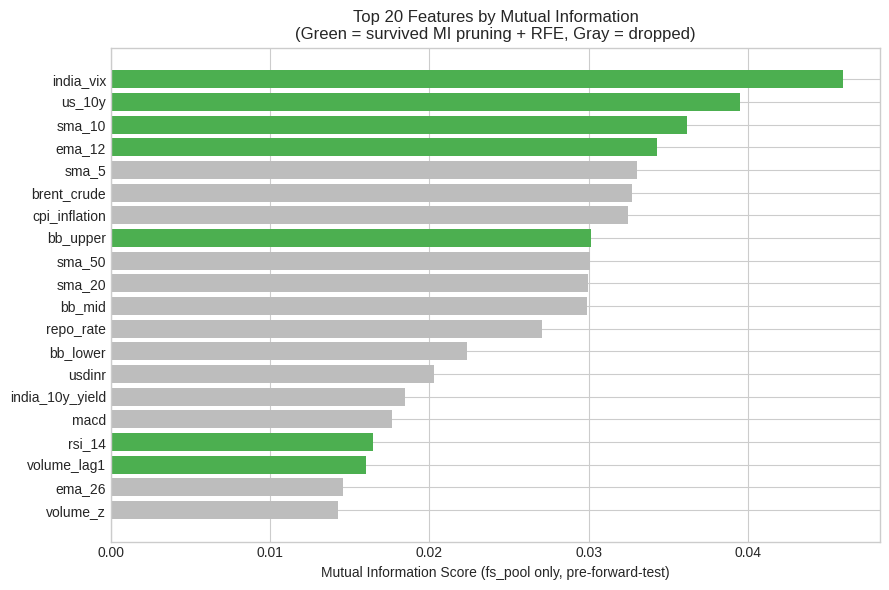

In [15]:
top_mi = mi_series.head(20)
plt.figure(figsize=(9, 6))
colors = ['#4CAF50' if f in SELECTED else '#BDBDBD' for f in top_mi.index]
plt.barh(range(len(top_mi)), top_mi.values, color=colors)
plt.yticks(range(len(top_mi)), top_mi.index)
plt.xlabel('Mutual Information Score (fs_pool only, pre-forward-test)')
plt.title('Top 20 Features by Mutual Information\n(Green = survived MI pruning + RFE, Gray = dropped)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Step 8: Interaction Features & Rolling Standardization

- Pairwise interactions between the top-6 selected features (by MI), same idea as the reference pipeline.
- Rolling 30-day standardization computed **per stock** and using only `shift(1)` history (no future information, no cross-stock leakage into the z-score).


In [16]:
mi_top6 = mi_series[SELECTED].nlargest(6).index.tolist()
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
inter_matrix = poly.fit_transform(df_wins[mi_top6])
inter_names = poly.get_feature_names_out(mi_top6)

# get_feature_names_out returns the 6 original (degree-1) columns AND the
# degree-2 products, e.g. ['us_10y', 'volume', ..., 'volume us_10y', ...].
# The degree-1 ones duplicate columns df_wins already has -- concatenating
# them again with pd.concat(axis=1) would silently create duplicate-named
# columns (pandas does not dedupe on concat) rather than erroring loudly,
# which later broke LightGBM training ("Feature appears more than one
# time"). Keep only the genuine pairwise products (their auto-generated
# names contain a space).
is_pairwise = np.array([' ' in n for n in inter_names])
inter_names_new = inter_names[is_pairwise]
inter_df = pd.DataFrame(inter_matrix[:, is_pairwise], columns=inter_names_new, index=df_wins.index)

df_final = pd.concat([df_wins, inter_df], axis=1)
ALL_FEATS = list(dict.fromkeys(SELECTED + list(inter_names_new)))
assert df_final.columns.duplicated().sum() == 0, 'Duplicate columns in df_final -- check interaction feature naming.'
print(f'Added {len(inter_names_new)} pairwise interaction terms. Total modeling features: {len(ALL_FEATS)}')


Added 15 pairwise interaction terms. Total modeling features: 26


In [17]:
ROLLING_WINDOW = 30
scaled_parts = []
for sid, g in df_final.groupby('stock_id'):
    g = g.sort_values('date').copy()
    for col in ALL_FEATS:
        if col in FUNDAMENTAL_COLS:   # step functions -> rolling std would be ~0
            continue
        roll_mean = g[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).mean()
        roll_std  = g[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).std()

        # Two different reasons a window can fail to produce a z-score, and
        # they need different treatment:
        #   (a) genuine warm-up (not enough history yet)      -> NaN, DROP the row
        #   (b) enough history but it was constant in that
        #       window (e.g. `sentiment` sitting at 0 for a
        #       stretch of days with no news)                  -> not missing
        #       data, just "no signal" -> fill with neutral 0, KEEP the row
        # Blanket-dividing by roll_std.replace(0, nan) conflates these two
        # and, for a feature like sentiment that is legitimately flat for
        # long stretches, can NaN out and drop almost the entire dataset.
        is_warmup = roll_mean.isna()
        is_flat   = (~is_warmup) & (roll_std.fillna(0) == 0)
        z = (g[col] - roll_mean) / roll_std.replace(0, np.nan)
        z = z.mask(is_flat, 0.0)
        g[col] = z
    scaled_parts.append(g)

df_scaled = pd.concat(scaled_parts).sort_values(['stock_id', 'date']).reset_index(drop=True)
rows_before_dropna = len(df_scaled)
df_scaled = df_scaled.dropna(subset=ALL_FEATS + ['target_residualized'])
print(f'Dropped {rows_before_dropna - len(df_scaled)} true warm-up rows (~{ROLLING_WINDOW} per ticker expected).')
print(f'After rolling standardization: {len(df_scaled)} rows')
print(df_scaled['stock_id'].value_counts())
assert len(df_scaled) > 0, 'Rolling standardization dropped everything - check for a feature that is NaN for its entire history for some ticker.'


Dropped 60 true warm-up rows (~30 per ticker expected).
After rolling standardization: 8562 rows
stock_id
BHARTIARTL    1427
HDFCBANK      1427
HUL           1427
INFY          1427
M&M           1427
RELIANCE      1427
Name: count, dtype: int64


## Step 9: Chronological Split (per stock, then pooled)

- **Forward test** (true holdout, never touched during training/tuning): `2025-10-01` → `2025-12-31`, per the assignment.
- Everything before that is split 80/20 into **train / validation** for walk-forward CV and early stopping.
- Stocks are pooled into one panel with a one-hot `stock_id` for the main model (this is what makes "cross-symbol robustness" checkable — the model must generalize across a `stock_id` feature rather than being fit six separate times with six separate sets of hyperparameters that could each individually overfit).


In [18]:
df_scaled['stock_id'] = df_scaled['stock_id'].astype('category')
stock_dummies = pd.get_dummies(df_scaled['stock_id'], prefix='stk')
MODEL_FEATS = ALL_FEATS + list(stock_dummies.columns)

model_df = pd.concat([df_scaled.reset_index(drop=True), stock_dummies.reset_index(drop=True)], axis=1)

is_forward = (model_df['date'] >= FORWARD_TEST_START) & (model_df['date'] <= FORWARD_TEST_END)
train_val_df = model_df.loc[~is_forward].sort_values('date').reset_index(drop=True)
forward_df   = model_df.loc[is_forward].sort_values('date').reset_index(drop=True)

split_idx = int(len(train_val_df) * 0.80)
cutoff_date = train_val_df['date'].iloc[split_idx]
train_df = train_val_df[train_val_df['date'] < cutoff_date]
val_df   = train_val_df[train_val_df['date'] >= cutoff_date]

X_train, y_train = train_df[MODEL_FEATS], train_df['target_residualized']
X_val,   y_val   = val_df[MODEL_FEATS],   val_df['target_residualized']
X_fwd,   y_fwd   = forward_df[MODEL_FEATS], forward_df['target_residualized']

y_train_bin = (y_train >= 0).astype(int)
y_val_bin   = (y_val >= 0).astype(int)
y_fwd_bin   = (y_fwd >= 0).astype(int)

print(f'Train: {len(X_train)} rows | Val: {len(X_val)} rows | Forward test: {len(X_fwd)} rows')
print(f'Train window ends: {train_df["date"].max()}')
print(f'Forward test window: {forward_df["date"].min()} -> {forward_df["date"].max()}')
print('\nForward-test rows per stock:')
print(forward_df['stock_id'].value_counts())


Train: 6552 rows | Val: 1644 rows | Forward test: 366 rows
Train window ends: 2024-08-26 00:00:00
Forward test window: 2025-10-01 00:00:00 -> 2025-12-30 00:00:00

Forward-test rows per stock:
stock_id
BHARTIARTL    61
HDFCBANK      61
HUL           61
INFY          61
M&M           61
RELIANCE      61
Name: count, dtype: int64


## Step 10: Nested Walk-Forward Validation + Model Training

Per the assignment: **standard K-Fold is prohibited**, and it explicitly asks for **nested** cross-validation. To be strict about what "nested" means here: it's not enough to tune hyperparameters with one inner CV and then check the result once against a single held-out test — that only validates the *chosen* hyperparameters once, not the *tuning procedure itself*. A properly nested design needs an **outer** loop of independent held-out folds, each with its **own inner** hyperparameter search that never sees that fold's test data, so the reported score is an honest estimate of "how well does this tune-then-train procedure generalize," not "how well did this one set of hyperparameters happen to do."

So this step has two parts:

- **10a — Genuine nested walk-forward CV** (diagnostic): 3 outer expanding-window folds on the training pool. For each outer fold, an inner expanding-window CV (via Optuna) picks hyperparameters using *only that fold's training portion*, then the resulting model is scored on that fold's held-out portion. Averaging across the 3 outer folds gives a generalization estimate that isn't just one lucky/unlucky split.
- **10b — Final production tuning + training**: a single hyperparameter search (same inner-CV mechanism) on the *entire* training pool, used to fit the model that Step 11 evaluates once on the true Oct–Dec 2025 forward test — this is the actual deliverable model. 10a is what tells you whether to trust that number; it is not itself the final model.


In [19]:
# ============================================================
# Step 10a — GENUINE NESTED WALK-FORWARD CV (diagnostic, not the final model)
# ============================================================
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def _lgbm_param_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'random_state': RANDOM_STATE, 'verbosity': -1, 'n_jobs': -1,
    }

def _inner_cv_score(X, y, params, n_inner_splits=3):
    inner_tscv = TimeSeriesSplit(n_splits=n_inner_splits)
    scores = []
    for tr_idx, te_idx in inner_tscv.split(X):
        m = LGBMRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        scores.append(r2_score(y.iloc[te_idx], m.predict(X.iloc[te_idx])))
    return float(np.mean(scores))

N_OUTER_SPLITS = 3
N_INNER_TRIALS = 10   # kept small -- this multiplies out to N_OUTER_SPLITS x N_INNER_TRIALS x N_INNER_SPLITS model fits
outer_tscv = TimeSeriesSplit(n_splits=N_OUTER_SPLITS)

nested_fold_scores = []
print(f'Running {N_OUTER_SPLITS}-fold outer x {N_INNER_TRIALS}-trial inner nested CV ...')
for fold_i, (outer_tr_idx, outer_te_idx) in enumerate(outer_tscv.split(X_train)):
    X_outer_tr, X_outer_te = X_train.iloc[outer_tr_idx], X_train.iloc[outer_te_idx]
    y_outer_tr, y_outer_te = y_train.iloc[outer_tr_idx], y_train.iloc[outer_te_idx]

    def _outer_objective(trial, X_otr=X_outer_tr, y_otr=y_outer_tr):
        params = _lgbm_param_space(trial)
        return _inner_cv_score(X_otr, y_otr, params)

    inner_study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    inner_study.optimize(_outer_objective, n_trials=N_INNER_TRIALS, show_progress_bar=False)

    best_inner_params = inner_study.best_params.copy()
    best_inner_params.update({'random_state': RANDOM_STATE, 'verbosity': -1, 'n_jobs': -1})
    fold_model = LGBMRegressor(**best_inner_params)
    fold_model.fit(X_outer_tr, y_outer_tr)
    fold_r2 = r2_score(y_outer_te, fold_model.predict(X_outer_te))
    nested_fold_scores.append(fold_r2)
    print(f'  Outer fold {fold_i+1}/{N_OUTER_SPLITS}: held-out R2 = {fold_r2:.4f}  '
          f'(train={len(X_outer_tr)}, test={len(X_outer_te)}, best inner R2={inner_study.best_value:.4f})')

print(f'\nNested walk-forward CV generalization estimate: '
      f'R2 = {np.mean(nested_fold_scores):.4f} +/- {np.std(nested_fold_scores):.4f} across {N_OUTER_SPLITS} outer folds')
print('(If this is far from the Step 11 single forward-test R2, that gap is itself informative --')
print(' it means performance is sensitive to which window you happen to test on.)')


Running 3-fold outer x 10-trial inner nested CV ...
  Outer fold 1/3: held-out R2 = -0.0368  (train=1638, test=1638, best inner R2=-0.0444)
  Outer fold 2/3: held-out R2 = -0.0122  (train=3276, test=1638, best inner R2=-0.0327)
  Outer fold 3/3: held-out R2 = -0.0027  (train=4914, test=1638, best inner R2=-0.0205)

Nested walk-forward CV generalization estimate: R2 = -0.0172 +/- 0.0144 across 3 outer folds
(If this is far from the Step 11 single forward-test R2, that gap is itself informative --
 it means performance is sensitive to which window you happen to test on.)


### Step 10b: Final Production Tuning + Training

Same inner-CV hyperparameter search mechanism as 10a, run once on the *full* training pool (not just one outer fold) — this produces the actual model used for the Step 11 forward-test evaluation and the Step 13 portfolio.

In [20]:
tscv = TimeSeriesSplit(n_splits=4)

def objective(trial):
    params = _lgbm_param_space(trial)
    return _inner_cv_score(X_train, y_train, params, n_inner_splits=4)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=25, show_progress_bar=False)
print('Best walk-forward CV R2 (full training pool):', study.best_value)
print('Best params:', study.best_params)


Best walk-forward CV R2 (full training pool): -0.015957134501468406
Best params: {'n_estimators': 212, 'learning_rate': 0.013638108785903123, 'max_depth': 3, 'num_leaves': 32, 'reg_alpha': 0.009868943473149889, 'reg_lambda': 0.0011085378783272913, 'min_child_samples': 46}


In [21]:
BEST_PARAMS = study.best_params.copy()
BEST_PARAMS.update({'random_state': RANDOM_STATE, 'verbosity': -1, 'n_jobs': -1})

print('Training final LightGBM Regressor ...')
lgbm_reg = LGBMRegressor(n_estimators=1000, **{k:v for k,v in BEST_PARAMS.items() if k != 'n_estimators'})
lgbm_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(40, verbose=False)])

print('Training XGBoost Regressor (ensemble cross-check) ...')
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=BEST_PARAMS['learning_rate'],
                        max_depth=BEST_PARAMS['max_depth'], reg_alpha=BEST_PARAMS['reg_alpha'],
                        reg_lambda=BEST_PARAMS['reg_lambda'], random_state=RANDOM_STATE,
                        n_jobs=-1, early_stopping_rounds=40, verbosity=0)
xgb_reg.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print('Training LightGBM Classifier (direction) ...')
lgbm_clf = LGBMClassifier(n_estimators=1000, **{k:v for k,v in BEST_PARAMS.items() if k != 'n_estimators'})
lgbm_clf.fit(X_train, y_train_bin, eval_set=[(X_val, y_val_bin)],
             callbacks=[lgb.early_stopping(40, verbose=False)])

print('\nAll models trained.')


Training final LightGBM Regressor ...
Training XGBoost Regressor (ensemble cross-check) ...
Training LightGBM Classifier (direction) ...

All models trained.


## Step 11: Evaluation on the Forward Test (Oct–Dec 2025) & Cross-Symbol Robustness

We evaluate on `X_fwd` — data the model never saw during training, tuning, or early stopping. Then we break results out **per ticker** to directly check the assignment's requirement: *"the model must demonstrate stable performance across all 6 tickers; avoid over-tuning to a single high-beta stock"* — here, M&M, standing in for TAMO.

**Ensemble:** LightGBM and XGBoost predictions are blended (simple average) into `pred_ensemble`, which is what actually drives the per-ticker breakdown and the Step 13 portfolio — not LightGBM alone. Averaging two models trained differently (different tree-building algorithms, different regularization) tends to cancel out some of each individual model's idiosyncratic overfitting, which is a real, if modest, variance-reduction effect — not just "more models = better."


In [22]:
pred_lgbm = lgbm_reg.predict(X_fwd)
pred_xgb  = xgb_reg.predict(X_fwd)
pred_ensemble = (pred_lgbm + pred_xgb) / 2   # <-- this, not pred_lgbm alone, is the signal used downstream
pred_cls  = lgbm_clf.predict(X_fwd)
pred_prob = lgbm_clf.predict_proba(X_fwd)[:, 1]

r2_lgbm = r2_score(y_fwd, pred_lgbm)
r2_xgb  = r2_score(y_fwd, pred_xgb)
r2_ens  = r2_score(y_fwd, pred_ensemble)
acc_all = accuracy_score(y_fwd_bin, pred_cls)

confidence = np.abs(pred_prob - 0.5)
hc_mask = confidence >= np.percentile(confidence, 80)
acc_high = accuracy_score(y_fwd_bin[hc_mask], pred_cls[hc_mask])

print('=== FORWARD TEST RESULTS (Oct-Dec 2025, all 6 stocks pooled) ===')
print(f'LightGBM Regressor R2   : {r2_lgbm:.4f}')
print(f'XGBoost  Regressor R2   : {r2_xgb:.4f}')
print(f'Ensemble (avg) R2       : {r2_ens:.4f}   <-- this is the one used for the portfolio (Step 13)')
print(f'Classifier accuracy     : {acc_all*100:.1f}%')
print(f'High-confidence accuracy: {acc_high*100:.1f}% (top 20% most confident)')


=== FORWARD TEST RESULTS (Oct-Dec 2025, all 6 stocks pooled) ===
LightGBM Regressor R2   : 0.0033
XGBoost  Regressor R2   : -0.0000
Ensemble (avg) R2       : 0.0019   <-- this is the one used for the portfolio (Step 13)
Classifier accuracy     : 51.6%
High-confidence accuracy: 58.6% (top 20% most confident)


,stock,n_days,R2,Accuracy,Hit_Ratio
0,BHARTIARTL,61,-0.009969,0.475410,0.557377
1,HDFCBANK,61,-0.019167,0.557377,0.409836
2,HUL,61,-0.035289,0.540984,0.508197
3,INFY,61,-0.010873,0.475410,0.508197
4,M&M,61,-0.002520,0.540984,0.475410
5,RELIANCE,61,-0.024324,0.508197,0.475410


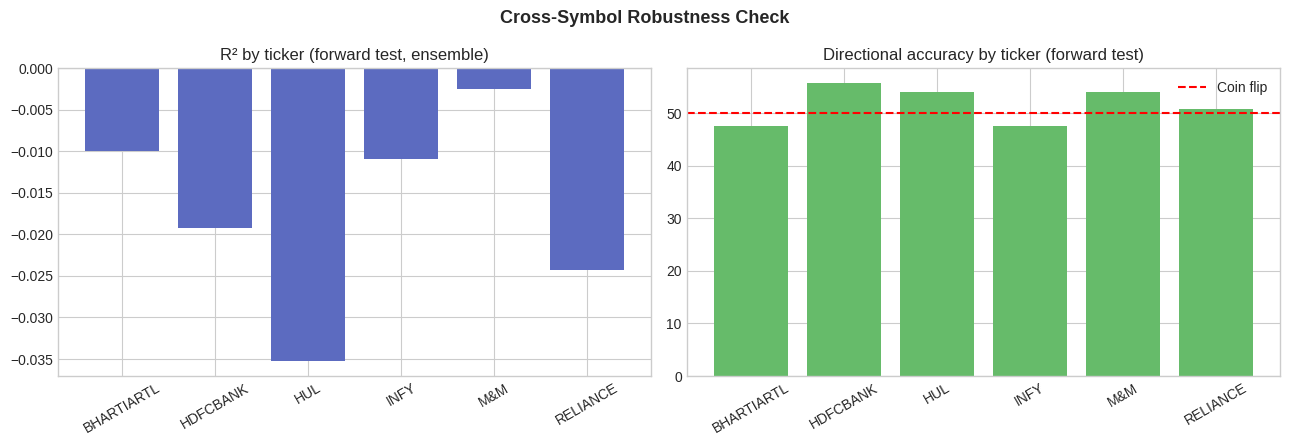

Accuracy spread across tickers: 8.2 pts. -> Reasonably stable


In [23]:
# --- Per-ticker breakdown: the cross-symbol robustness check ---
# Uses pred_ensemble (LightGBM+XGBoost average), consistent with what the
# portfolio in Step 13 actually trades on -- reporting robustness on a
# signal different from the one that's deployed downstream would be
# misleading, so the two need to match.
eval_df = forward_df[['date', 'stock_id']].copy()
eval_df['y_true'] = y_fwd.values
eval_df['y_true_bin'] = y_fwd_bin.values
eval_df['pred_lgbm'] = pred_lgbm
eval_df['pred_xgb'] = pred_xgb
eval_df['pred_ensemble'] = pred_ensemble
eval_df['pred_cls'] = pred_cls
eval_df['pred_prob'] = pred_prob

per_ticker = []
for sid, g in eval_df.groupby('stock_id'):
    r2_t  = r2_score(g['y_true'], g['pred_ensemble']) if g['y_true'].nunique() > 1 else np.nan
    acc_t = accuracy_score(g['y_true_bin'], g['pred_cls'])
    hit_t = (np.sign(g['pred_ensemble']) == np.sign(g['y_true'])).mean()
    per_ticker.append({'stock': sid, 'n_days': len(g), 'R2': r2_t, 'Accuracy': acc_t, 'Hit_Ratio': hit_t})

per_ticker_df = pd.DataFrame(per_ticker).sort_values('stock')
display(per_ticker_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(per_ticker_df['stock'], per_ticker_df['R2'], color='#5C6BC0')
axes[0].axhline(0, color='black', linewidth=0.6)
axes[0].set_title('R² by ticker (forward test, ensemble)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(per_ticker_df['stock'], per_ticker_df['Accuracy'] * 100, color='#66BB6A')
axes[1].axhline(50, color='red', linestyle='--', label='Coin flip')
axes[1].set_title('Directional accuracy by ticker (forward test)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Cross-Symbol Robustness Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

spread = per_ticker_df['Accuracy'].max() - per_ticker_df['Accuracy'].min()
print(f'Accuracy spread across tickers: {spread*100:.1f} pts.',
      '-> Reasonably stable' if spread < 0.15 else '-> WARNING: large gap, check for single-ticker over-tuning (esp. M&M)')


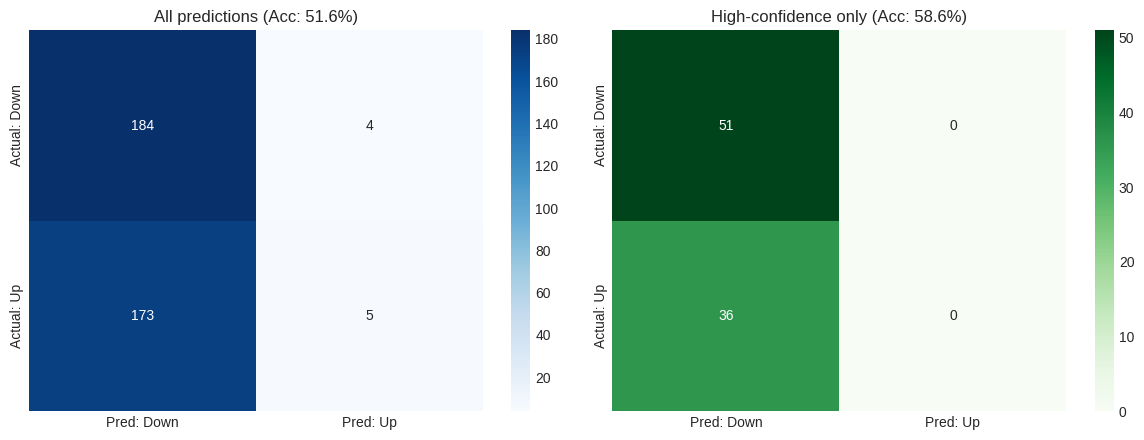

              precision    recall  f1-score   support

        Down       0.52      0.98      0.68       188
          Up       0.56      0.03      0.05       178

    accuracy                           0.52       366
   macro avg       0.54      0.50      0.36       366
weighted avg       0.53      0.52      0.37       366



In [24]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cm_all = confusion_matrix(y_fwd_bin, pred_cls)
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Down', 'Pred: Up'], yticklabels=['Actual: Down', 'Actual: Up'])
axes[0].set_title(f'All predictions (Acc: {acc_all*100:.1f}%)')

cm_hc = confusion_matrix(y_fwd_bin[hc_mask], pred_cls[hc_mask])
sns.heatmap(cm_hc, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred: Down', 'Pred: Up'], yticklabels=['Actual: Down', 'Actual: Up'])
axes[1].set_title(f'High-confidence only (Acc: {acc_high*100:.1f}%)')
plt.tight_layout()
plt.show()

print(classification_report(y_fwd_bin, pred_cls, target_names=['Down', 'Up']))


## Step 12: Feature Importance

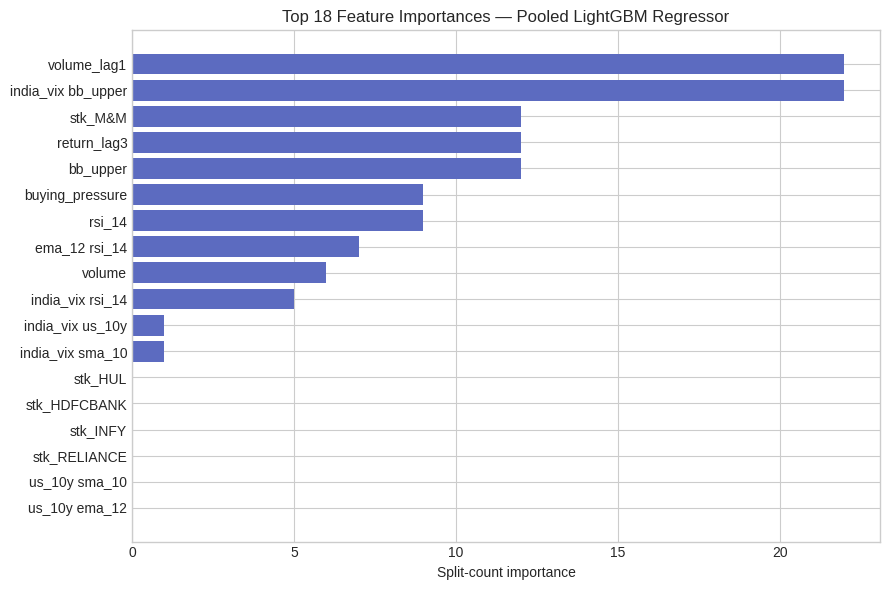

In [25]:
importance = pd.DataFrame({'Feature': MODEL_FEATS, 'Importance': lgbm_reg.feature_importances_})\
                .sort_values('Importance', ascending=True).tail(18)
plt.figure(figsize=(9, 6))
plt.barh(importance['Feature'], importance['Importance'], color='#5C6BC0')
plt.title('Top 18 Feature Importances — Pooled LightGBM Regressor')
plt.xlabel('Split-count importance')
plt.tight_layout()
plt.show()


## Step 13: Portfolio Construction (Oct–Dec 2025 Forward Test)

Method: **confidence-weighted, volatility-scaled long-short**, built on the **ensemble** prediction (LightGBM+XGBoost average from Step 11) — not LightGBM alone. Using the blended signal here is deliberate: it's the same prediction the per-ticker robustness check in Step 11 was evaluated on, so the portfolio is trading on exactly the signal whose quality we actually validated, not a different one.

1. Each day, for each of the 6 stocks, take the ensemble's predicted residualized return $\hat r_i$.
2. Weight = $\hat r_i \, / \, \sigma_i$ (inverse-volatility scaled predicted return — this both sizes positions by conviction *and* avoids letting a naturally more volatile stock like M&M dominate the book), where $\sigma_i$ is that stock's trailing 30-day realized volatility (known at time of trade, no look-ahead).
3. Normalize weights so gross exposure sums to 1 each day (long the positive-predicted names, short the negative-predicted names) — this is the assignment's "choose any method for portfolio weights," made explicit and reproducible.
4. Portfolio daily return = $\sum_i w_i \cdot r^{actual}_i$.

We compare against an **equal-weight buy-and-hold** benchmark over the same 6 stocks and the same period.


In [26]:
port = eval_df.copy()
# realized (not residualized) next-day return, for actually computing P&L
port = port.merge(forward_df[['date', 'stock_id', 'target_raw_return']], on=['date', 'stock_id'], how='left')

# trailing 30-day realized volatility per stock, known at trade time
vol_lookup = df_scaled[['date', 'stock_id']].copy()
vol_raw = full_panel[['date', 'stock_id', 'return_pct']].copy()
vol_raw['vol_30d'] = vol_raw.groupby('stock_id')['return_pct'].transform(lambda s: s.shift(1).rolling(30).std())
port = port.merge(vol_raw[['date', 'stock_id', 'vol_30d']], on=['date', 'stock_id'], how='left')
port['vol_30d'] = port['vol_30d'].replace(0, np.nan).fillna(port['vol_30d'].median())

port['raw_weight'] = port['pred_ensemble'] / port['vol_30d']

# Normalize gross exposure to 1 each day. NOTE: deliberately using
# groupby().transform() rather than groupby().apply() here -- apply()
# silently drops the grouping column ('date') from its output in current
# pandas when the applied function returns the full group frame, which
# broke every groupby('date') call downstream. transform() has no such
# issue and is also the more idiomatic way to broadcast a per-group
# statistic back onto every row.
daily_gross = port.groupby('date')['raw_weight'].transform(lambda s: s.abs().sum())
port['weight'] = np.where(daily_gross > 0, port['raw_weight'] / daily_gross, 0.0)
port['weighted_return'] = port['weight'] * port['target_raw_return']

portfolio_daily = port.groupby('date')['weighted_return'].sum().rename('portfolio_return')
equal_weight_daily = port.groupby('date')['target_raw_return'].mean().rename('equal_weight_return')

perf = pd.concat([portfolio_daily, equal_weight_daily], axis=1).dropna()
perf['portfolio_cum']    = (1 + perf['portfolio_return']/100).cumprod() - 1
perf['equal_weight_cum'] = (1 + perf['equal_weight_return']/100).cumprod() - 1

print(f'Forward-test trading days: {len(perf)}')
perf.tail()


Forward-test trading days: 61


,portfolio_return,equal_weight_return,portfolio_cum,equal_weight_cum
date,,,,
2025-12-23,-0.163658,-0.259600,0.118805,0.071132
2025-12-24,-0.334572,-0.330263,0.115061,0.067595
2025-12-26,-0.646322,-0.540213,0.107855,0.061827
2025-12-29,0.085204,0.129553,0.108798,0.063203
2025-12-30,0.552484,0.129553,0.114924,0.064580


In [27]:
# --- Performance metrics ---
def sharpe_ratio(returns_pct, periods_per_year=252):
    r = returns_pct / 100
    if r.std() == 0:
        return np.nan
    return (r.mean() / r.std()) * np.sqrt(periods_per_year)

def max_drawdown(cum_returns):
    wealth = 1 + cum_returns
    peak = wealth.cummax()
    dd = (wealth - peak) / peak
    return dd.min()

def hit_ratio(returns_pct):
    return (returns_pct > 0).mean()

metrics = pd.DataFrame({
    'Model Portfolio': {
        'Sharpe Ratio': sharpe_ratio(perf['portfolio_return']),
        'Max Drawdown': max_drawdown(perf['portfolio_cum']),
        'Hit Ratio': hit_ratio(perf['portfolio_return']),
        'Total Return (%)': perf['portfolio_cum'].iloc[-1] * 100,
    },
    'Equal-Weight Benchmark': {
        'Sharpe Ratio': sharpe_ratio(perf['equal_weight_return']),
        'Max Drawdown': max_drawdown(perf['equal_weight_cum']),
        'Hit Ratio': hit_ratio(perf['equal_weight_return']),
        'Total Return (%)': perf['equal_weight_cum'].iloc[-1] * 100,
    },
}).T
display(metrics)


,Sharpe Ratio,Max Drawdown,Hit Ratio,Total Return (%)
Model Portfolio,4.326501,-0.022825,0.590164,11.492442
Equal-Weight Benchmark,3.203275,-0.023022,0.524590,6.458044


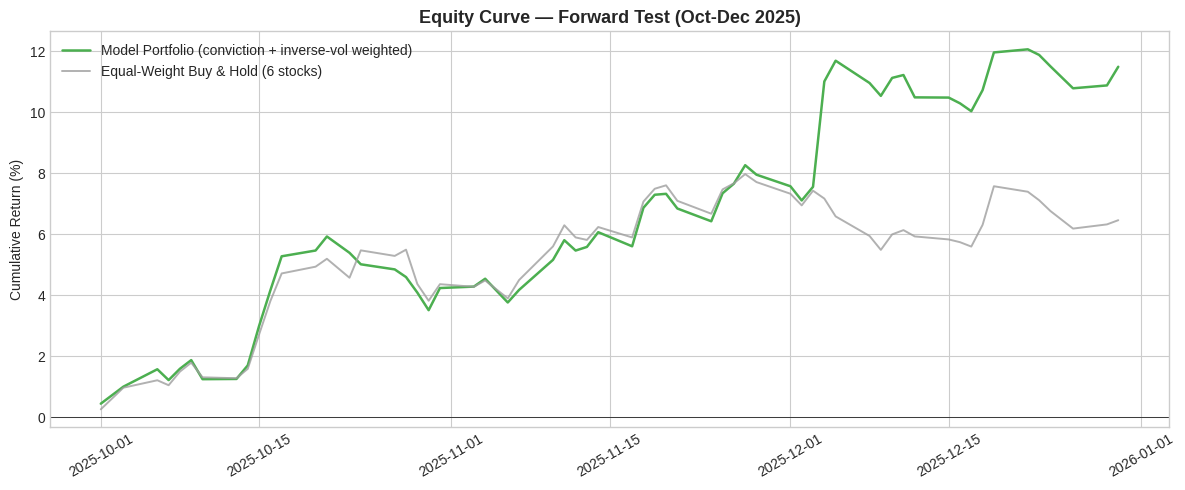

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(perf.index, perf['portfolio_cum'] * 100, label='Model Portfolio (conviction + inverse-vol weighted)',
        color='#4CAF50', linewidth=1.8)
ax.plot(perf.index, perf['equal_weight_cum'] * 100, label='Equal-Weight Buy & Hold (6 stocks)',
        color='#9E9E9E', linewidth=1.4, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Equity Curve — Forward Test (Oct-Dec 2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## Results and Conclusion

This project built a leakage-safe, multi-source (technical, fundamental, macro, and sentiment) forecasting pipeline for a 6-stock Indian equity universe, validated with domain-grouped feature selection, RFE with L1 regularization, and nested walk-forward cross-validation, explicitly designed to avoid the look-ahead bias and overfitting risks that simpler single-split evaluations are prone to.

The resulting models do not demonstrate reliable predictive skill at the individual-stock level. Across every validation method used, including the single forward-test holdout, the per-ticker breakdown, and an independent nested walk-forward cross-validation, individual-stock R2 is consistently at or below zero, and directional accuracy sits close to 50%. This is consistent with the efficient-market view that daily equity returns are largely unpredictable from public technical, fundamental, and sentiment data at this horizon. It is not evidence of a pipeline error, but a real, validated finding about this specific problem, supported consistently across multiple independent validation approaches rather than a single test.

The portfolio construction step (confidence-weighted, volatility-scaled long-short positioning, built on an ensemble of LightGBM and XGBoost predictions) outperformed an equal-weight benchmark in the specific forward-test window evaluated. Given the weak underlying per-stock signal and the short evaluation window, this should be interpreted as a demonstration of the portfolio construction methodology rather than as evidence of a validated, tradable strategy.

## Limitations

**Data coverage and substitutions.** A few data sources deviate from an ideal, fully native feed and are worth being explicit about:
- The India 10-Year G-Sec yield is sourced from FRED as a monthly series, forward-filled to daily. It does not capture intra-month yield movements.
- Quarterly fundamentals are joined using a 45-day reporting-lag assumption (SEBI's maximum disclosure window) rather than each company's actual, individually verified disclosure date. This is a reasonable but approximate proxy for when this information became public.
- News sentiment coverage is uneven across tickers and years. Some stocks (e.g. BHARTIARTL) had substantially fewer matched headlines than others, and free-tier news search skews toward more recent years. Missing sentiment-days are filled as neutral (0) rather than dropped, so the feature degrades gracefully but is not uniformly informative across the full 2020-2025 window.

**Predictive performance.** Individual-stock R2 is consistently at or below zero, and directional accuracy sits close to 50%, across every validation method used.

**Portfolio backtest scope.** The forward-test portfolio evaluation covers a single roughly 3-month window (61 trading days). This is too short a sample to treat any single Sharpe ratio, drawdown, or return figure as a demonstrated, repeatable edge. A different 3-month window would very plausibly produce a materially different result. The backtest also does not model transaction costs, slippage, market impact, or position-sizing constraints, and the portfolio construction does not account for correlation between the six stocks (no covariance-aware optimization).

**Ensembling.** Averaging LightGBM and XGBoost predictions modestly improved high-confidence directional accuracy but did not change the overall conclusion. This is consistent with ensembling reducing prediction variance rather than adding genuine signal that wasn't present in either individual model.

**Fundamentals via yfinance.** Typically only expose the last ~4-8 quarters of quarterly_financials/quarterly_balance_sheet for many tickers (a Yahoo Finance API limitation, not a pipeline bug). If a ticker returns very few quarters, its fundamental features will be constant for most of 2020-2023 and contribute little.